# Raw vs Preprocessed FHR Signal Comparison

This notebook visualises ECG/CTG signals from the raw dataset (.dat/.hea)
and compares them with the corresponding preprocessed CSV files
(records 1001–1005) to verify the effectiveness of the preprocessing pipeline.


In [1]:
# imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import wfdb
from pathlib import Path

In [2]:
# Paths
RAW_PATH = Path("../data/raw_dataset")
CLEAN_PATH = Path("../cleaned_data/clean_csv")


In [3]:
records = ["1001", "1002", "1003", "1004", "1008", "1035"]

In [4]:
'''
Function to load raw signals
'''
def load_raw_record(record_id):
    record = wfdb.rdrecord(str(RAW_PATH / record_id))
    signal = record.p_signal[:, 0]  # first channel
    fs = record.fs
    return signal, fs



In [5]:
'''
Function to load cleaned signal 
'''
def load_clean_record(record_id):
    df = pd.read_csv(CLEAN_PATH / f"{record_id}.csv")
    return df


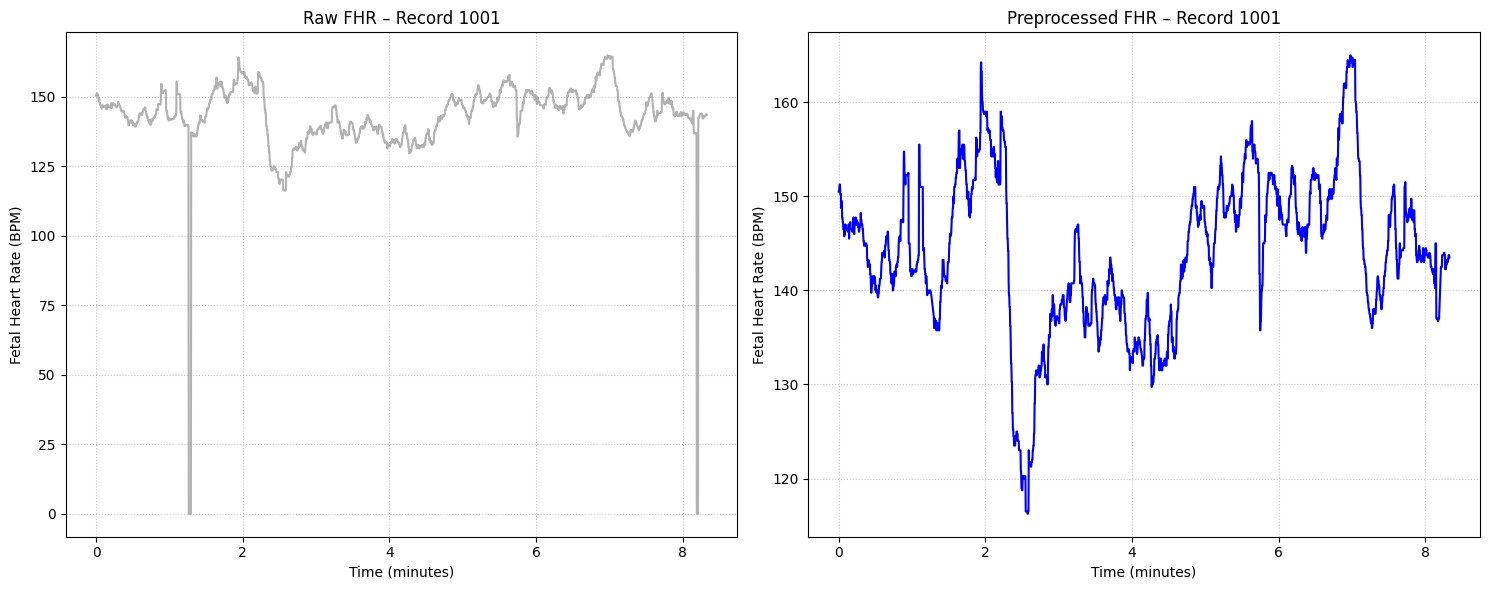

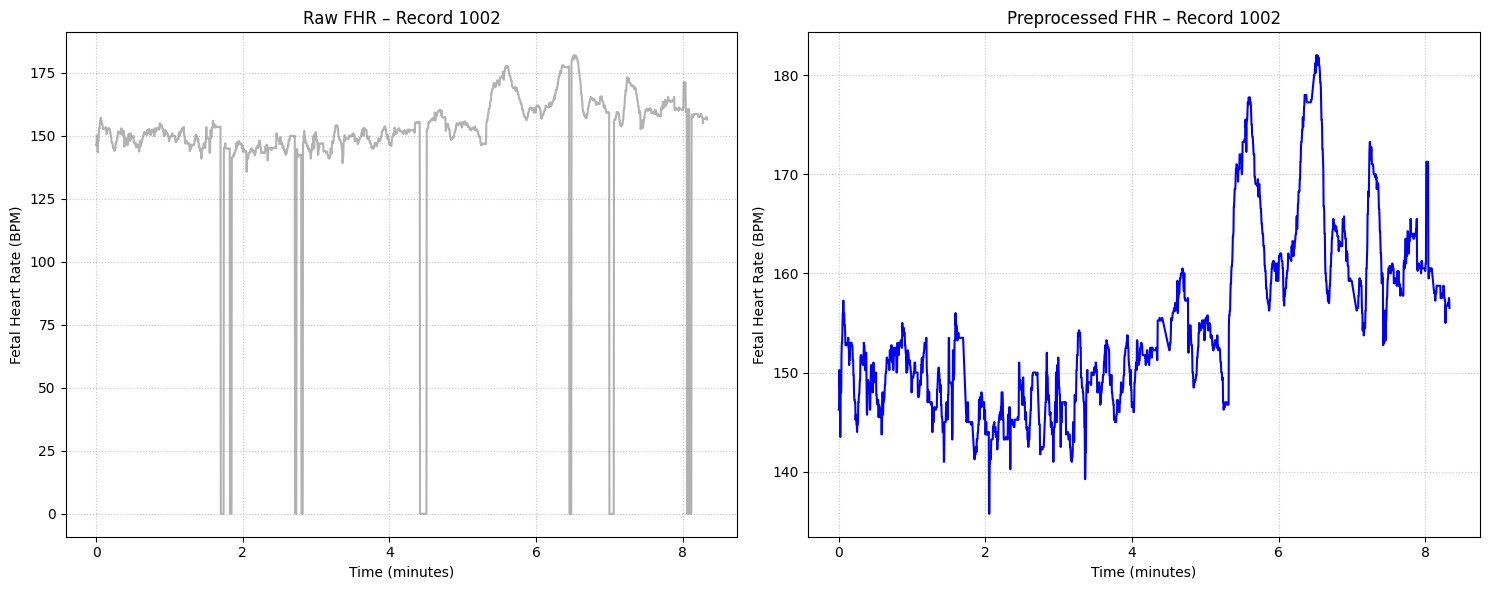

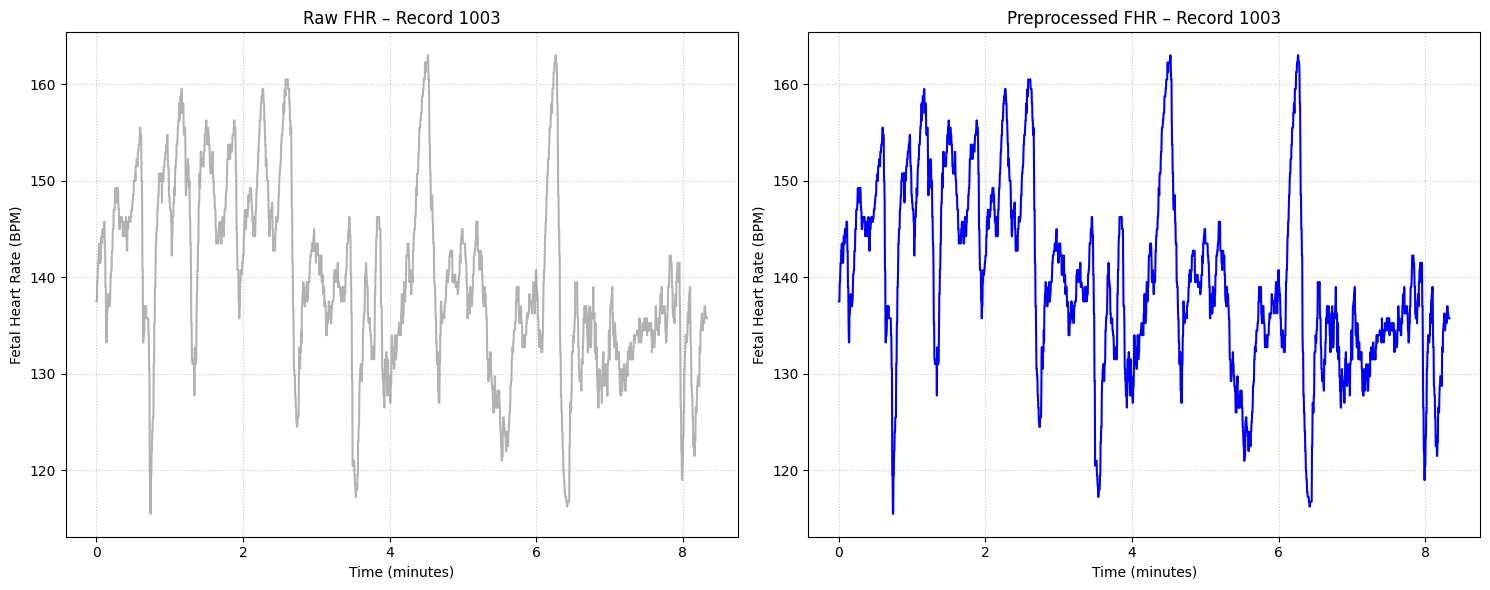

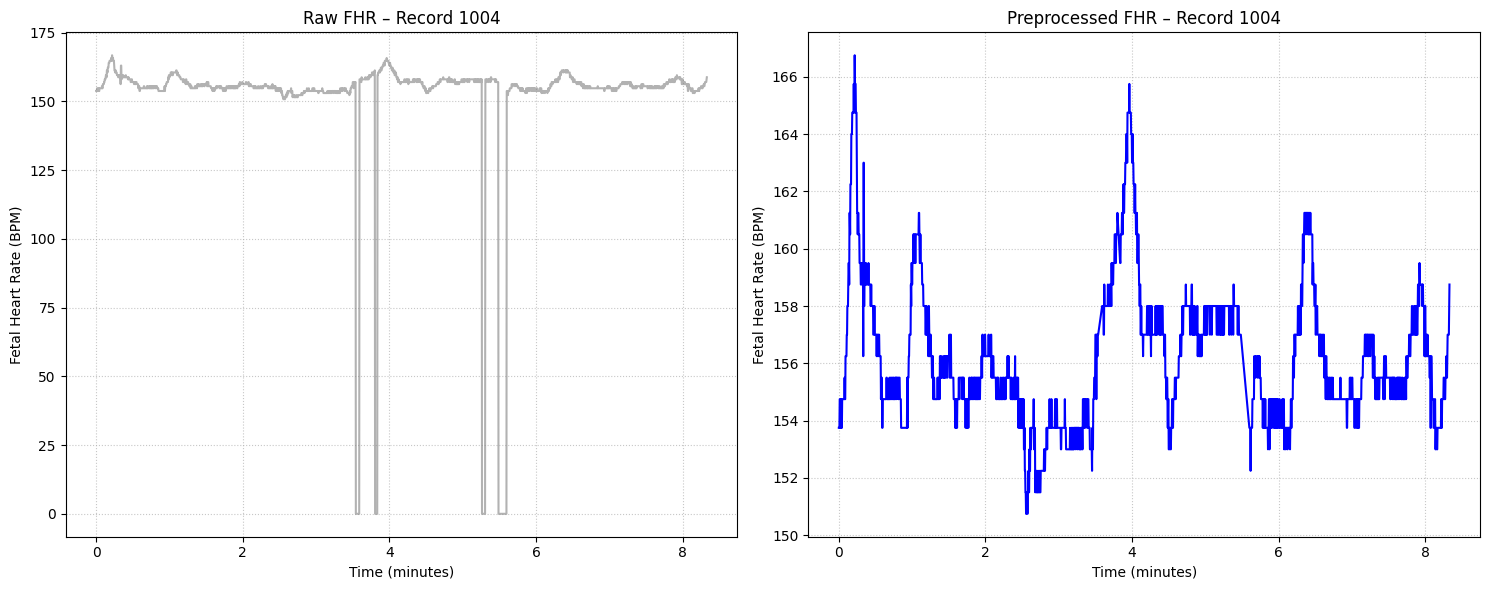

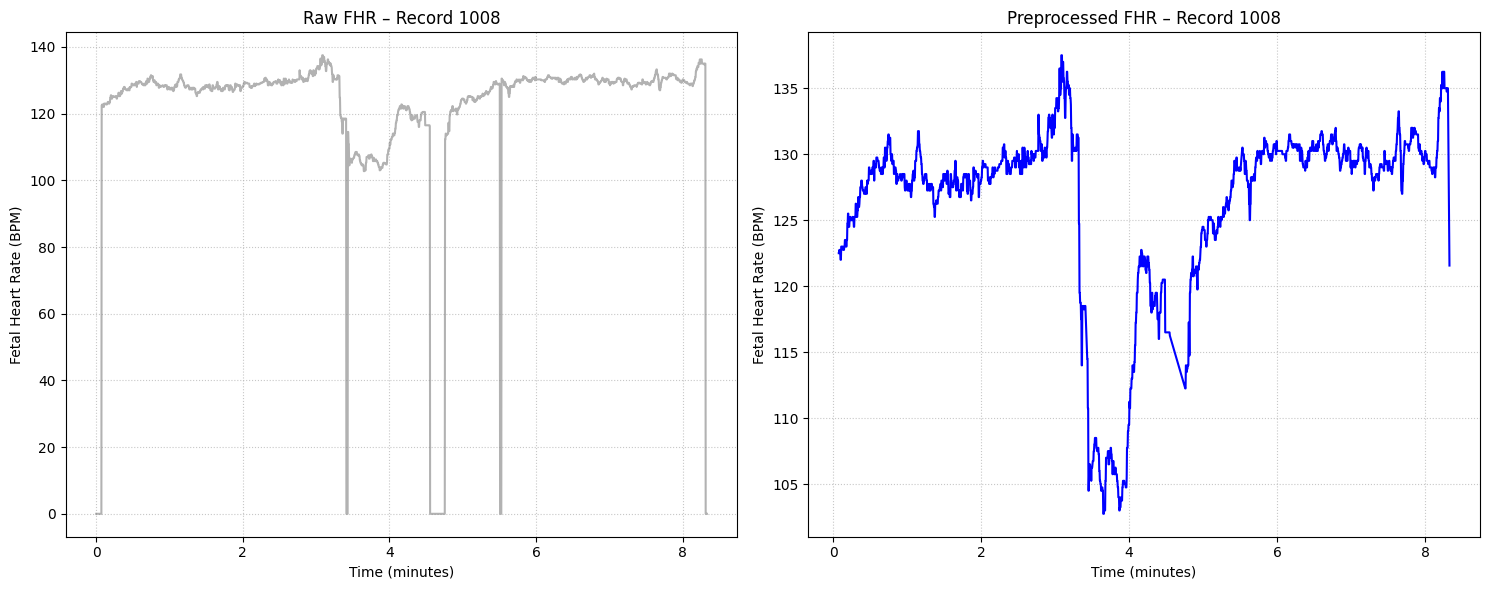

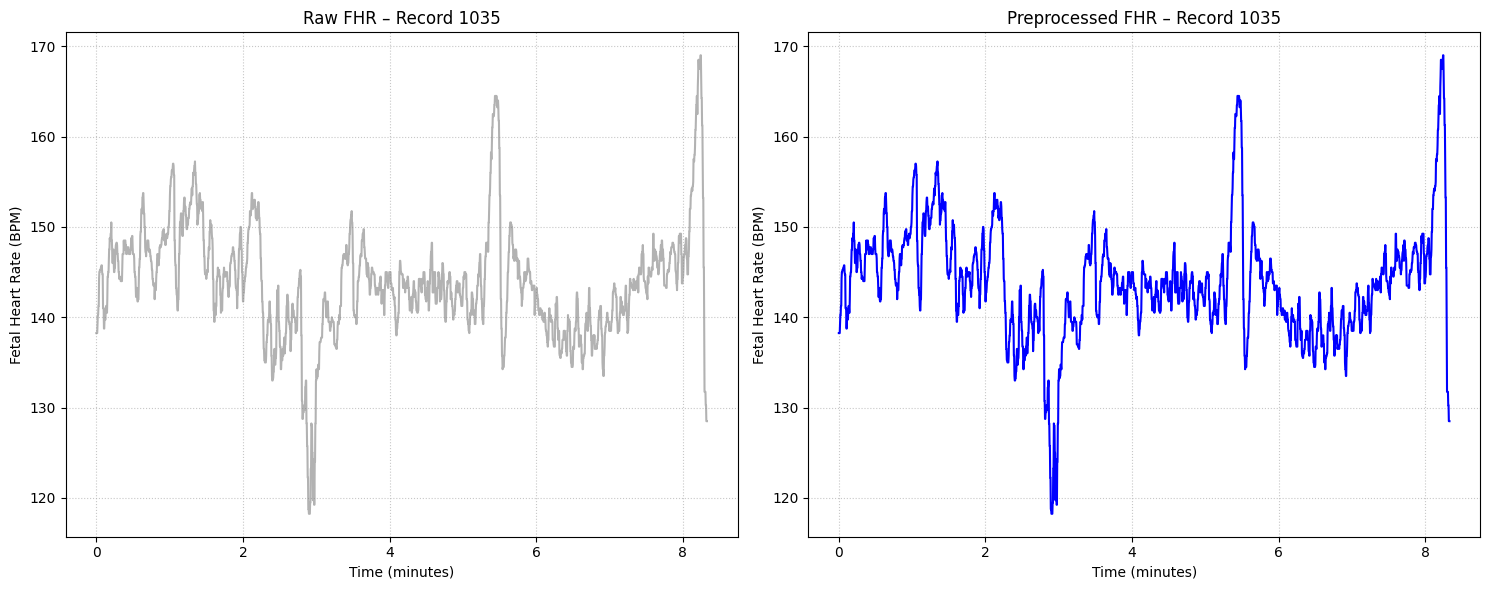

In [6]:
# The sampling frequency for this dataset is fixed at 4 Hz
fs = 4 

for rec in records:
    raw_signal, _ = load_raw_record(rec)
    clean_df = load_clean_record(rec)

    # 1. Create a time array in minutes
    # Time (min) = Sample Index / (fs * 60)
    time_raw = np.arange(len(raw_signal)) / (fs * 60)
    time_clean = np.arange(len(clean_df)) / (fs * 60)

    plt.figure(figsize=(15, 6))

    # --- Plot 1: Raw Signal ---
    plt.subplot(1, 2, 1)
    # We slice both time and signal to keep them aligned (e.g., first 2000 samples)
    plt.plot(time_raw[:2000], raw_signal[:2000], color='gray', alpha=0.6)
    plt.title(f"Raw FHR – Record {rec}")
    plt.xlabel("Time (minutes)")
    plt.ylabel("Fetal Heart Rate (BPM)")
    plt.grid(True, linestyle=':', alpha=0.7)

    # --- Plot 2: Preprocessed Signal ---
    plt.subplot(1, 2, 2)
    plt.plot(time_clean[:2000], clean_df.iloc[:2000, 0], color='blue')
    plt.title(f"Preprocessed FHR – Record {rec}")
    plt.xlabel("Time (minutes)")
    plt.ylabel("Fetal Heart Rate (BPM)")
    plt.grid(True, linestyle=':', alpha=0.7)

    plt.tight_layout()
    plt.show()

In [7]:
'''
Enhanced visual comparison with multiple plots and statistics
'''

def enhanced_comparison(rec):
    """Enhanced comparison with multiple plots"""
    raw_signal, fs = load_raw_record(rec)
    clean_df = load_clean_record(rec)
    
    if raw_signal is None or clean_df is None:
        print(f"Skipping record {rec} due to loading issues")
        return
    
    if len(clean_df.columns) > 0:
        clean_signal = clean_df.iloc[:, 0].values
    else:
        print(f"No data in clean record {rec}")
        return
    
    # Make sure same length for comparison
    min_len = min(len(raw_signal), len(clean_signal))
    raw_signal = raw_signal[:min_len]
    clean_signal = clean_signal[:min_len]
    
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    axes = axes.flatten()
    
    # 1. Overlay comparison
    axes[0].plot(raw_signal[:2000], label='Raw', alpha=0.7, linewidth=1)
    axes[0].plot(clean_signal[:2000], label='Cleaned', alpha=0.7, linewidth=1)
    axes[0].set_title(f"Record {rec} - Overlay Comparison")
    axes[0].set_xlabel("Samples")
    axes[0].set_ylabel("Amplitude")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # 2. Distribution comparison
    axes[1].hist(raw_signal, bins=100, alpha=0.5, label='Raw', density=True, color='blue')
    axes[1].hist(clean_signal, bins=100, alpha=0.5, label='Cleaned', density=True, color='orange')
    axes[1].set_title("Amplitude Distribution")
    axes[1].set_xlabel("Amplitude")
    axes[1].set_ylabel("Density")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    # 3. Difference signal
    diff_signal = raw_signal - clean_signal
    axes[2].plot(diff_signal[:2000], color='red', alpha=0.7, linewidth=1)
    axes[2].axhline(y=0, color='black', linestyle='-', alpha=0.3)
    axes[2].set_title("Difference (Raw - Cleaned)")
    axes[2].set_xlabel("Samples")
    axes[2].set_ylabel("Difference")
    axes[2].grid(True, alpha=0.3)
    
    # 4. Zoomed comparison
    zoom_start = 500
    zoom_end = 1000
    axes[3].plot(raw_signal[zoom_start:zoom_end], label='Raw', alpha=0.7, linewidth=1.5)
    axes[3].plot(clean_signal[zoom_start:zoom_end], label='Cleaned', alpha=0.7, linewidth=1.5)
    axes[3].set_title(f"Zoomed View (Samples {zoom_start}-{zoom_end})")
    axes[3].set_xlabel("Samples")
    axes[3].set_ylabel("Amplitude")
    axes[3].legend()
    axes[3].grid(True, alpha=0.3)
    
    # 5. Statistical metrics (as text)
    axes[4].axis('off')
    
    # Calculate metrics
    metrics = {
        'Raw Mean': f"{np.mean(raw_signal):.4f}",
        'Clean Mean': f"{np.mean(clean_signal):.4f}",
        'Raw Std': f"{np.std(raw_signal):.4f}",
        'Clean Std': f"{np.std(clean_signal):.4f}",
        'Noise Power': f"{np.mean(diff_signal**2):.6f}",
        'SNR (dB)': f"{10*np.log10(np.mean(clean_signal**2)/np.mean(diff_signal**2)):.2f}" if np.mean(diff_signal**2) > 0 else "Inf",
        'Max Diff': f"{np.max(np.abs(diff_signal)):.4f}"
    }
    
    # 6. Rolling standard deviation (noise level over time)
    window_size = 100
    rolling_raw_std = pd.Series(raw_signal[:2000]).rolling(window=window_size).std().values
    rolling_clean_std = pd.Series(clean_signal[:2000]).rolling(window=window_size).std().values
    
    axes[5].plot(rolling_raw_std, label='Raw Std', alpha=0.7, linewidth=1)
    axes[5].plot(rolling_clean_std, label='Clean Std', alpha=0.7, linewidth=1)
    axes[5].set_title(f"Rolling Std Dev (window={window_size})")
    axes[5].set_xlabel("Samples")
    axes[5].set_ylabel("Standard Deviation")
    axes[5].legend()
    axes[5].grid(True, alpha=0.3)
    
    plt.suptitle(f"Preprocessing Analysis - Record {rec}", fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # Print numerical summary
    print(f"ANALYSIS SUMMARY - Record {rec}")
    print(f"Signal length: {len(raw_signal)} samples")
    print(f"Sampling rate: {fs} Hz")
    print(f"Duration: {len(raw_signal)/fs:.2f} seconds")
    print(f"Mean reduction: {np.mean(raw_signal) - np.mean(clean_signal):.4f}")
    print(f"Std reduction: {np.std(raw_signal) - np.std(clean_signal):.4f}")
    print(f"Max absolute difference: {np.max(np.abs(diff_signal)):.4f}")



In [8]:
'''
Quantitative metrics table calculation and display
'''

def calculate_metrics_table():
    """Calculate and display comprehensive metrics table"""
    all_metrics = []
    
    for rec in records:
        print(f"Processing record {rec}...")
        
        raw_signal, fs = load_raw_record(rec)
        clean_df = load_clean_record(rec)
        
        if raw_signal is None or clean_df is None:
            continue
            
        if len(clean_df.columns) > 0:
            clean_signal = clean_df.iloc[:, 0].values
        else:
            continue
            
        # Ensure same length
        min_len = min(len(raw_signal), len(clean_signal))
        raw = raw_signal[:min_len]
        clean = clean_signal[:min_len]
        diff = raw - clean
        
        # Calculate metrics
        metrics = {
            'Record': rec,
            'Length': len(raw),
            'FS': fs,
            'Raw Mean': np.mean(raw),
            'Clean Mean': np.mean(clean),
            'Raw Std': np.std(raw),
            'Clean Std': np.std(clean),
            'Mean Diff': np.mean(diff),
            'Noise Power': np.mean(diff**2),
            'SNR (dB)': 10*np.log10(np.mean(clean**2)/np.mean(diff**2)) if np.mean(diff**2) > 0 else np.inf,
            'Max Abs Diff': np.max(np.abs(diff)),
            'Correlation': np.corrcoef(raw, clean)[0, 1]
        }
        
        all_metrics.append(metrics)
    
    # Create DataFrame
    if all_metrics:
        metrics_df = pd.DataFrame(all_metrics)
        metrics_df.set_index('Record', inplace=True)
        
        # Display formatted table
        print("PREPROCESSING PERFORMANCE METRICS")
        
        # Format the display
        display_cols = ['Length', 'FS', 'Raw Mean', 'Clean Mean', 'Raw Std', 'Clean Std', 
                       'SNR (dB)', 'Correlation', 'Max Abs Diff']
        
        formatted_df = metrics_df[display_cols].copy()
        formatted_df['SNR (dB)'] = formatted_df['SNR (dB)'].apply(lambda x: f"{x:.1f}" if x < 1000 else "Inf")
        formatted_df['Correlation'] = formatted_df['Correlation'].apply(lambda x: f"{x:.4f}")
        formatted_df['Raw Mean'] = formatted_df['Raw Mean'].apply(lambda x: f"{x:.4f}")
        formatted_df['Clean Mean'] = formatted_df['Clean Mean'].apply(lambda x: f"{x:.4f}")
        formatted_df['Raw Std'] = formatted_df['Raw Std'].apply(lambda x: f"{x:.4f}")
        formatted_df['Clean Std'] = formatted_df['Clean Std'].apply(lambda x: f"{x:.4f}")
        formatted_df['Max Abs Diff'] = formatted_df['Max Abs Diff'].apply(lambda x: f"{x:.4f}")
        
        print(formatted_df.to_string())
        
        # Summary statistics
        print("SUMMARY STATISTICS")
        print(f"Average SNR improvement: {metrics_df['SNR (dB)'].mean():.1f} dB")
        print(f"Average correlation: {metrics_df['Correlation'].mean():.4f}")
        print(f"Average std reduction: {(metrics_df['Raw Std'] - metrics_df['Clean Std']).mean():.4f}")
        print(f"Total records analyzed: {len(metrics_df)}")
        
        return metrics_df
    else:
        print("No data could be loaded. Check file paths and record IDs.")
        return None

Starting preprocessing analysis...
Records to analyze: ['1001', '1002', '1003', '1004', '1008', '1035']

Generating visualization for record 1001...


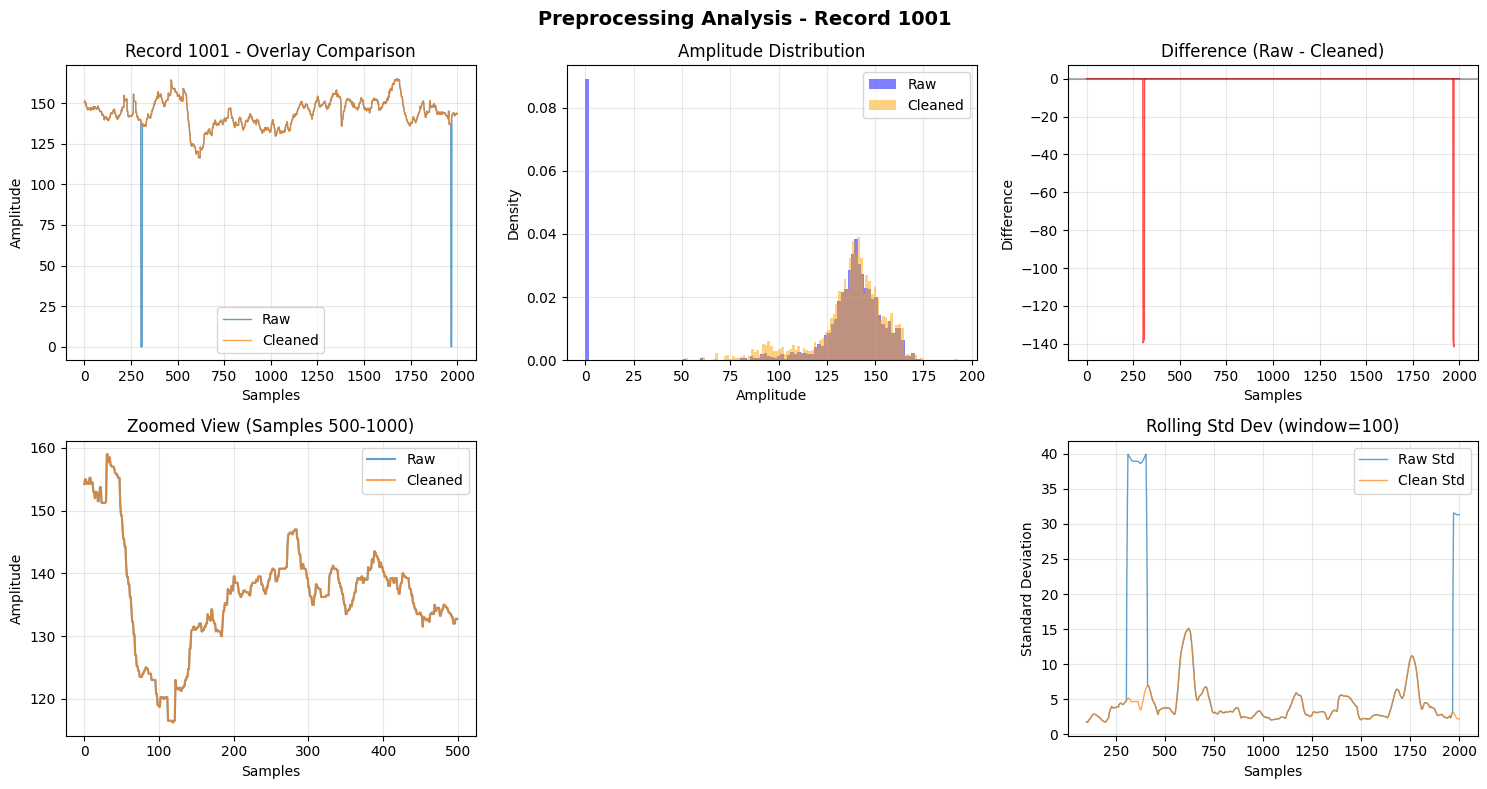

ANALYSIS SUMMARY - Record 1001
Signal length: 16324 samples
Sampling rate: 4 Hz
Duration: 4081.00 seconds
Mean reduction: -18.4682
Std reduction: 32.9913
Max absolute difference: 193.0000

Generating visualization for record 1002...


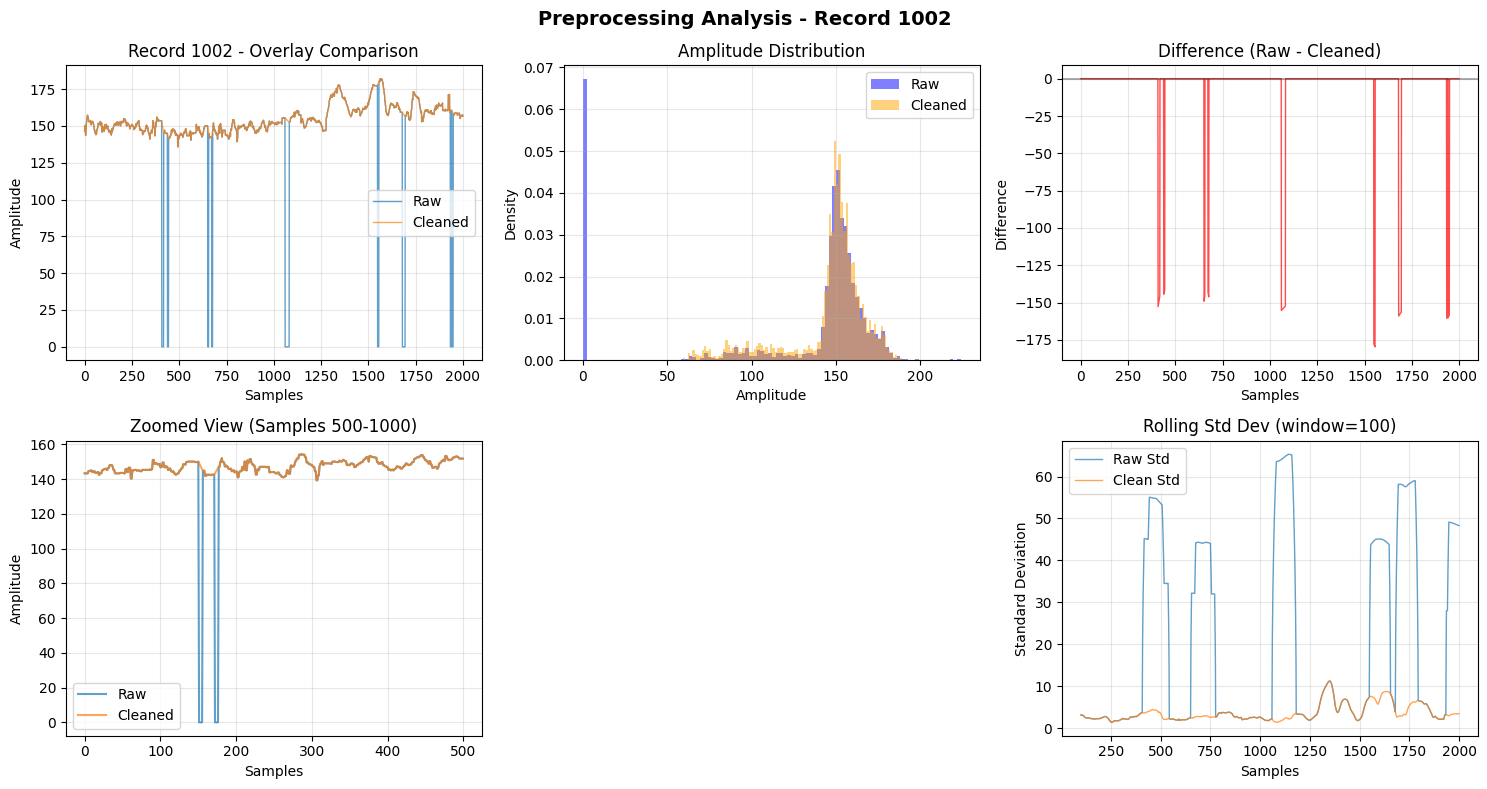

ANALYSIS SUMMARY - Record 1002
Signal length: 17758 samples
Sampling rate: 4 Hz
Duration: 4439.50 seconds
Mean reduction: -18.8887
Std reduction: 32.5506
Max absolute difference: 191.9423

Generating visualization for record 1003...


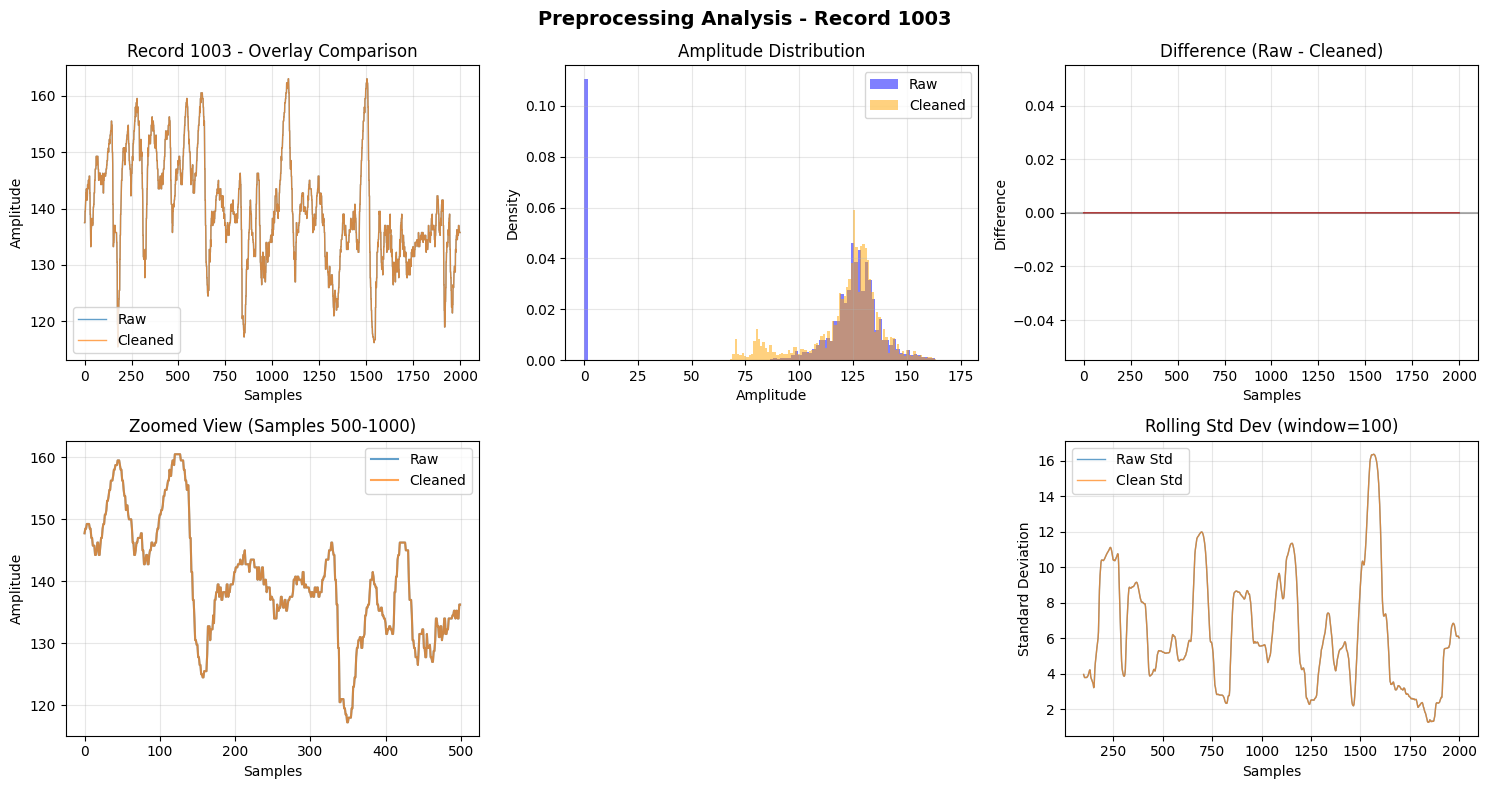

ANALYSIS SUMMARY - Record 1003
Signal length: 14679 samples
Sampling rate: 4 Hz
Duration: 3669.75 seconds
Mean reduction: -17.6970
Std reduction: 32.1471
Max absolute difference: 145.7500

Generating visualization for record 1004...


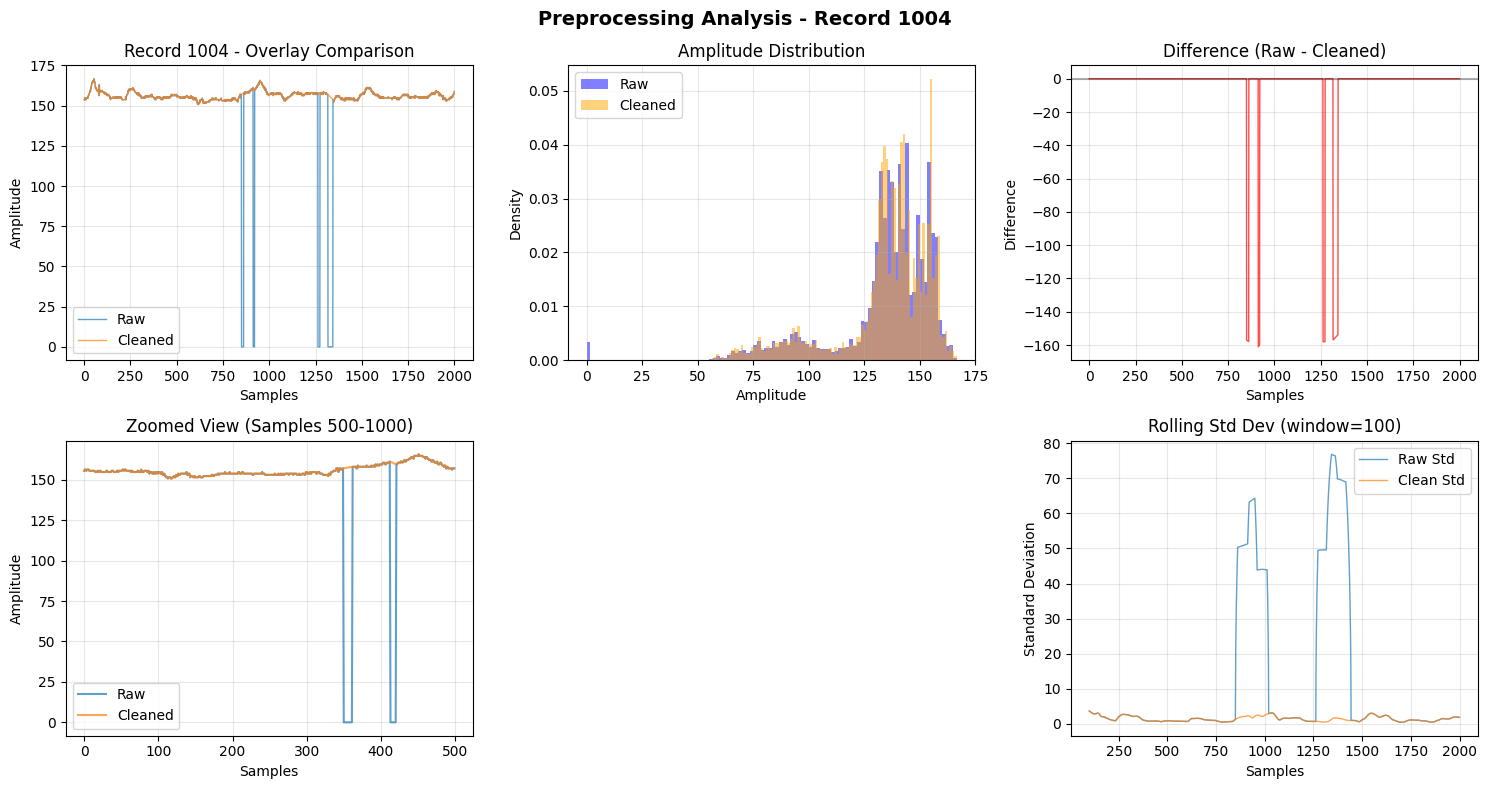

ANALYSIS SUMMARY - Record 1004
Signal length: 16671 samples
Sampling rate: 4 Hz
Duration: 4167.75 seconds
Mean reduction: -0.7219
Std reduction: 2.1129
Max absolute difference: 161.0556

Generating visualization for record 1008...


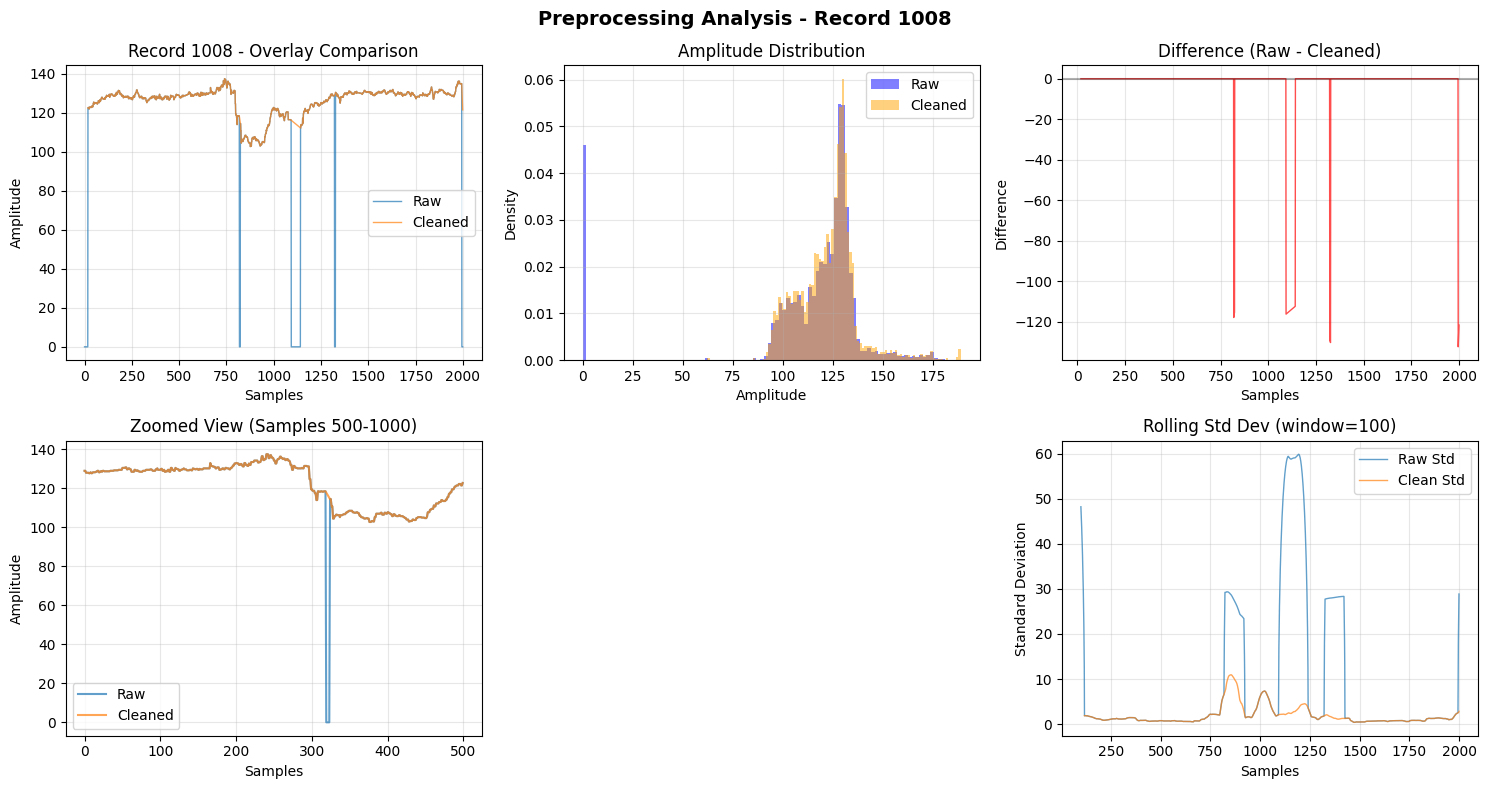

ANALYSIS SUMMARY - Record 1008
Signal length: 16667 samples
Sampling rate: 4 Hz
Duration: 4166.75 seconds
Mean reduction: nan
Std reduction: nan
Max absolute difference: nan

Generating visualization for record 1035...


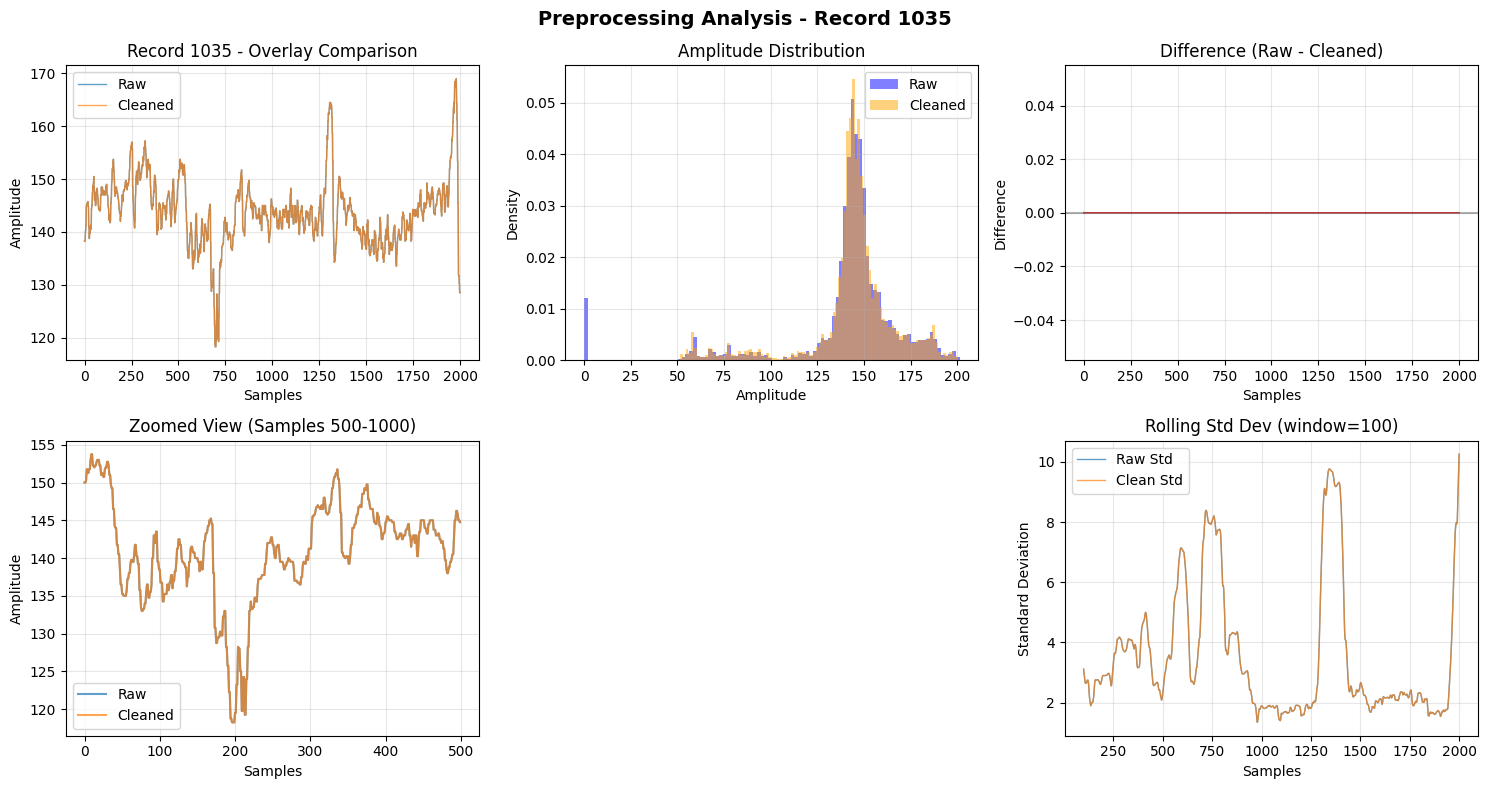

ANALYSIS SUMMARY - Record 1035
Signal length: 16800 samples
Sampling rate: 4 Hz
Duration: 4200.00 seconds
Mean reduction: -2.5813
Std reduction: 7.7125
Max absolute difference: 189.4531
CALCULATING QUANTITATIVE METRICS
Processing record 1001...
Processing record 1002...
Processing record 1003...
Processing record 1004...
Processing record 1008...
Processing record 1035...
PREPROCESSING PERFORMANCE METRICS
        Length  FS  Raw Mean Clean Mean  Raw Std Clean Std SNR (dB) Correlation Max Abs Diff
Record                                                                                      
1001     16324   4  117.7989   136.2670  52.3498   19.3585      7.8      0.1646     193.0000
1002     17758   4  126.9803   145.8690  56.8124   24.2618      8.2      0.3227     191.9423
1003     14679   4  103.8626   121.5596  49.6784   17.5313      6.9     -0.0081     145.7500
1004     16671   4  134.0595   134.7814  23.3864   21.2736     22.7      0.9053     161.0556
1008     16667   4  111.9371     

In [9]:
'''
Run the analysis
'''

if __name__ == "__main__":
    print("Starting preprocessing analysis...")
    print(f"Records to analyze: {records}")
    
    # First, run the enhanced visualizations
    for rec in records:
        print(f"\nGenerating visualization for record {rec}...")
        enhanced_comparison(rec)
    
    #generate the metrics table
    print("CALCULATING QUANTITATIVE METRICS")
    metrics_df = calculate_metrics_table()

# CTG / FHR Signal Analysis and Preprocessing

## Key Characteristics of FHR Signals

- **FHR is not zero-mean**: Heart rate values are absolute (in bpm) and should not be mean-centered.
- **Variability is non-stationary**: FHR characteristics change over time and must be analysed locally.
- **Artifacts dominate global statistics**: Signal dropouts and noise can heavily bias global metrics such as mean and standard deviation.


## How FHR Is Analysed in CTG

In cardiotocography (CTG), we analyse a time series of fetal heart rate (FHR) values in beats per minute (bpm), typically sampled at low frequency (e.g. 4 Hz).

Clinically and academically, FHR analysis is based on four core components:

1. Baseline  
2. Variability  
3. Accelerations  
4. Decelerations  


## Baseline

**Definition:**  
The baseline is the average FHR during a stable period, excluding accelerations and decelerations.

**Clinical interpretation:**
- **110–160 bpm** → Normal baseline  
- **< 110 bpm** → Bradycardia  
- **> 160 bpm** → Tachycardia  

Baseline in CTG is a physiological reference level, not a zero-centered signal.


## Variability

**Definition:**  
Variability refers to short-term fluctuations around the baseline and reflects fetal autonomic nervous system activity.

### Clinical Variability Categories (FIGO)

| Variability (bpm) | Interpretation |
|------------------|----------------|
| 0–2              | Pathological   |
| 3–5              | Suspicious     |
| 6–25             | Normal         |
| >25              | Abnormal       |

### Why Windowed Analysis Is Required

Global standard deviation is misleading because it is computed over:
- Hours of data
- Accelerations
- Decelerations
- Artifacts and signal dropouts

**Proper variability analysis therefore:**
- Uses 30–60 second windows
- Excludes acceleration and deceleration periods

## Accelerations

**Definition:**  
An acceleration is:
- An increase of ≥ 15 bpm
- Lasting ≥ 15 seconds

**Clinical significance:**  
Accelerations indicate fetal well-being and good oxygenation.

## Decelerations

**Definition:**  
A deceleration is:
- A decrease of ≥ 15 bpm
- Lasting ≥ 15 seconds

Decelerations are clinically important and may indicate fetal stress, depending on their type and timing.

## Raw Signal Analysis (Record 1002)

The raw FHR signal is artifact-dominated and cannot be used directly for analysis or modelling.

### Observed Issues

- Multiple abrupt drops to 0 bpm, consistent with probe dropout / signal loss
- Severe inflation of global statistics due to non-physiological values

### Raw Signal Statistics

- **Raw mean:** 126.98 bpm  
  - Artificially low due to zero-valued dropouts
- **Raw standard deviation:** 56.81 bpm  
  - Extremely high for FHR  
  - Driven by large deviations from the mean caused by artifacts

## Effects of Preprocessing

### 1. Artifact Handling
- Zero-value dropouts are successfully removed or interpolated.
- Signal continuity is restored.

### 2. Baseline Correction
- **Clean mean:** 145.87 bpm  
- **Mean increase:** +18.89 bpm  
- This shift aligns with the removal of non-physiological zero values and reflects a realistic FHR baseline.

### 3. Variability Normalisation
- **Clean standard deviation:** 24.26 bpm  
- **Standard deviation reduction:** −32.55 bpm  

Typical short-term FHR variability lies in the range 5–25 bpm, meaning the cleaned signal falls within a clinically reasonable range.

## Identified Limitations

### 1. Large Maximum Absolute Difference
- **Max absolute difference:** 191.94 bpm  
- Likely caused by aggressive interpolation over long dropout segments.
- Some reconstructed regions may be physiologically unrealistic despite visual smoothness.

### 2. Low Correlation with Raw Signal
- **Correlation:** 0.3227  
- Expected due to removal of large non-physiological segments.
- Indicates preservation of global trends, not point-wise fidelity.
- Acceptable for most FHR analysis tasks.

### 3. Signal-to-Noise Ratio (SNR)
- **SNR:** 8.2 dB  
- Lower than cleaner records due to heavy corruption in the raw signal.
- SNR is limited in interpretability when raw data is artifact-dominated.

## Potential Improvements

- Limit interpolation over long gaps
- Detect dropout segments longer than 10–15 seconds
- Mask long invalid regions instead of interpolating
- Apply post-interpolation slope constraints  
  - Enforce maximum rate of change (e.g. ≤ 5 bpm/s)
- Report the percentage of reconstructed samples
  - Provides context for correlation and SNR values

## Overall Assessment

This preprocessing approach is well-suited for:
- CNN and deep learning models
- Pattern recognition
- Baseline trend analysis
- Classification tasks (e.g. normal vs pathological CTG)

The pipeline improves signal consistency and physiological realism, while sacrificing exact micro-variability fidelity. This trade-off is appropriate for machine learning applications, as CNNs learn patterns and trends rather than exact point-wise values.

However, the processed signal should not be used for precise clinical variability metrics without additional masking and constraints.
